In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
!file /societial_data.csv

/societial_data.csv: Microsoft OOXML


In [9]:
df = pd.read_excel('/societial_data.csv')

df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,SR No.,Road Name,From,To,Length (m),Width (m),Surface,Condition
0,1,Sitkendra to Hatdiya,Sitkendra,hatdiya,800,10–14,Asphalt,good
1,2,hatdiya to vishwakarma mandir,hatdiya,Vishwakarma mandir,550,10–14,cc,good
2,3,kharikui to railway station,kharikui,railway station,1100,10–14,Asphalt,good
3,4,kharikui to sang,kharikui,sang,550,10–14,Asphalt,moderate
4,5,hatdiya to jama masjid,hatdiya,jama masjid,700,7–9,cc,moderate


In [12]:
print("Shape:", df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
df.info()

Shape: (17, 8)

Columns
Index(['SR No.', 'Road Name', 'From', 'To', 'Length (m)', 'Width (m)',
       'Surface', 'Condition'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SR No.      17 non-null     int64 
 1   Road Name   17 non-null     object
 2   From        17 non-null     object
 3   To          17 non-null     object
 4   Length (m)  17 non-null     int64 
 5   Width (m)   17 non-null     object
 6   Surface     17 non-null     object
 7   Condition   17 non-null     object
dtypes: int64(2), object(6)
memory usage: 1.2+ KB


In [13]:
df.isnull().sum()

,0
SR No.,0
Road Name,0
From,0
To,0
Length (m),0
Width (m),0
Surface,0
Condition,0


In [14]:
df.describe(include='all')

,SR No.,Road Name,From,To,Length (m),Width (m),Surface,Condition
count,17.000000,17,17,17,17.000000,17,17,17
unique,NaN,17,11,14,NaN,4,3,2
top,NaN,Sitkendra to Hatdiya,kharikui,sang,NaN,7-9,cc,good
freq,NaN,1,3,2,NaN,6,7,9
mean,9.000000,NaN,NaN,NaN,685.294118,NaN,NaN,NaN
std,5.049752,NaN,NaN,NaN,150.794465,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,500.000000,NaN,NaN,NaN
25%,5.000000,NaN,NaN,NaN,550.000000,NaN,NaN,NaN
50%,9.000000,NaN,NaN,NaN,650.000000,NaN,NaN,NaN
75%,13.000000,NaN,NaN,NaN,800.000000,NaN,NaN,NaN


In [15]:
df["Surface"] = df["Surface"].str.title()
df["Condition"] = df["Condition"].str.title()

df.head()

,SR No.,Road Name,From,To,Length (m),Width (m),Surface,Condition
0,1,Sitkendra to Hatdiya,Sitkendra,hatdiya,800,10–14,Asphalt,Good
1,2,hatdiya to vishwakarma mandir,hatdiya,Vishwakarma mandir,550,10–14,Cc,Good
2,3,kharikui to railway station,kharikui,railway station,1100,10–14,Asphalt,Good
3,4,kharikui to sang,kharikui,sang,550,10–14,Asphalt,Moderate
4,5,hatdiya to jama masjid,hatdiya,jama masjid,700,7–9,Cc,Moderate


In [16]:
def avg_width(x):
    x = str(x).replace("–","-")
    a,b = x.split("-")
    return (float(a)+float(b))/2

df["Average Width"] = df["Width (m)"].apply(avg_width)

df.head()

,SR No.,Road Name,From,To,Length (m),Width (m),Surface,Condition,Average Width
0,1,Sitkendra to Hatdiya,Sitkendra,hatdiya,800,10–14,Asphalt,Good,12.0
1,2,hatdiya to vishwakarma mandir,hatdiya,Vishwakarma mandir,550,10–14,Cc,Good,12.0
2,3,kharikui to railway station,kharikui,railway station,1100,10–14,Asphalt,Good,12.0
3,4,kharikui to sang,kharikui,sang,550,10–14,Asphalt,Moderate,12.0
4,5,hatdiya to jama masjid,hatdiya,jama masjid,700,7–9,Cc,Moderate,8.0


In [17]:
print("Total Roads :",len(df))

Total Roads : 17


In [18]:
total = df["Length (m)"].sum()

print("Total Length :",total,"meters")

print("Total Length :",round(total/1000,2),"km")

Total Length : 11650 meters
Total Length : 11.65 km


In [19]:
print(df["Length (m)"].mean())

685.2941176470588


In [20]:
df.sort_values("Length (m)",ascending=False).head(1)

,SR No.,Road Name,From,To,Length (m),Width (m),Surface,Condition,Average Width
2,3,kharikui to railway station,kharikui,railway station,1100,10–14,Asphalt,Good,12.0


In [21]:
df.sort_values("Length (m)").head(1)

,SR No.,Road Name,From,To,Length (m),Width (m),Surface,Condition,Average Width
5,6,main bajar to Limbach mata mandir,main bajar,Limbach mata mandir,500,7–9,Cc,Moderate,8.0


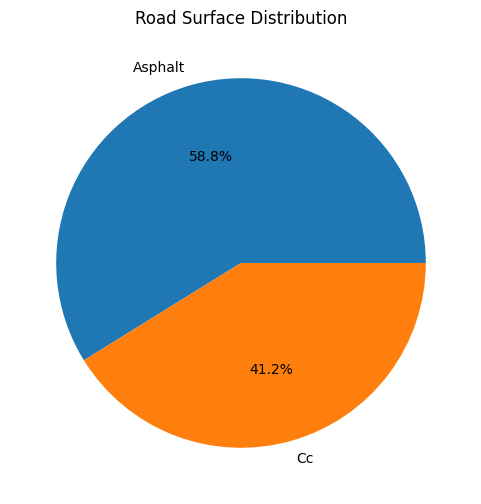

In [22]:
surface = df["Surface"].value_counts()

surface.plot(kind="pie",
             autopct="%1.1f%%",
             figsize=(6,6))

plt.title("Road Surface Distribution")

plt.ylabel("")

plt.show()

In [24]:
df["Surface"].value_counts()

,count
Surface,
Asphalt,10
Cc,7


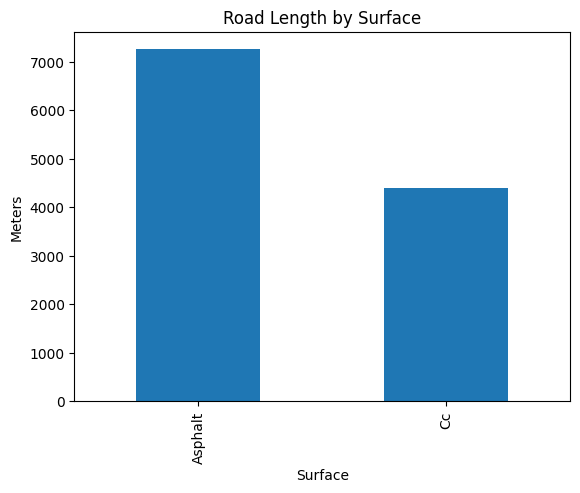

In [26]:
length=df.groupby("Surface")["Length (m)"].sum()

length.plot(kind="bar")

plt.ylabel("Meters")

plt.title("Road Length by Surface")

plt.show()

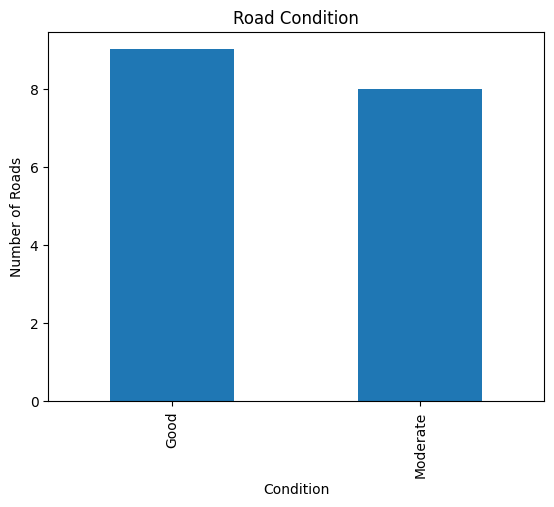

In [23]:
condition=df["Condition"].value_counts()

condition.plot(kind="bar")

plt.title("Road Condition")

plt.xlabel("Condition")

plt.ylabel("Number of Roads")

plt.show()

In [25]:
df["Condition"].value_counts()

,count
Condition,
Good,9
Moderate,8


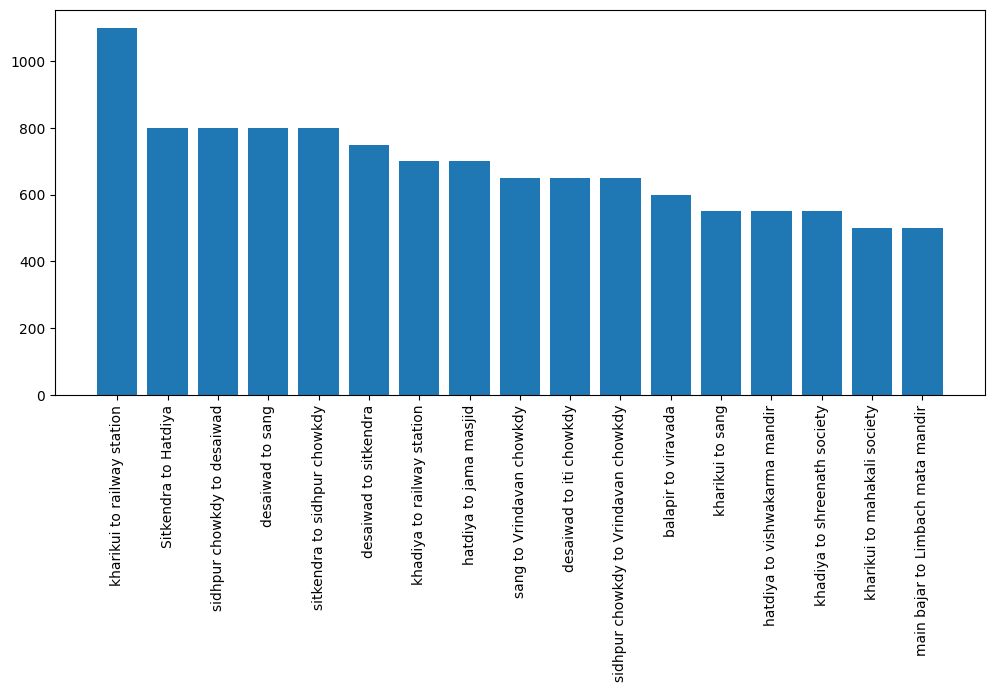

In [27]:
top=df.sort_values("Length (m)",ascending=False)

plt.figure(figsize=(12,5))

plt.bar(top["Road Name"],top["Length (m)"])

plt.xticks(rotation=90)

plt.show()

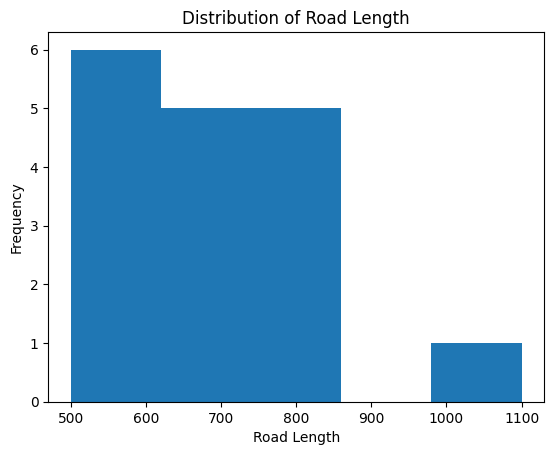

In [28]:
plt.hist(df["Length (m)"],bins=5)

plt.xlabel("Road Length")

plt.ylabel("Frequency")

plt.title("Distribution of Road Length")

plt.show()

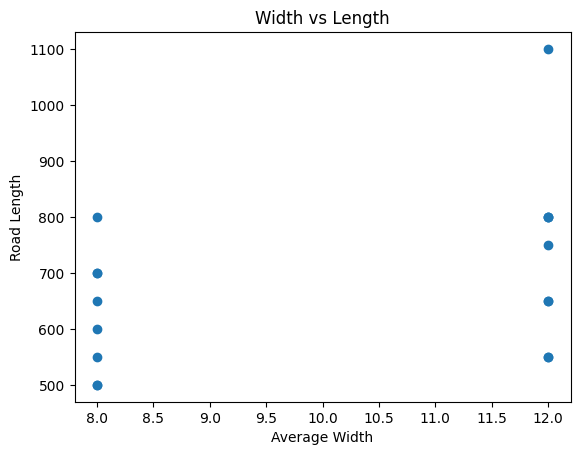

In [29]:
plt.scatter(df["Average Width"],df["Length (m)"])

plt.xlabel("Average Width")

plt.ylabel("Road Length")

plt.title("Width vs Length")

plt.show()

In [30]:
df.corr(numeric_only=True)

,SR No.,Length (m),Average Width
SR No.,1.000000,-0.143636,-0.096225
Length (m),-0.143636,1.000000,0.388578
Average Width,-0.096225,0.388578,1.000000


In [31]:
summary={

"Total Roads":[len(df)],

"Total Length (km)":[round(df["Length (m)"].sum()/1000,2)],

"Average Length":[round(df["Length (m)"].mean(),2)],

"Average Width":[round(df["Average Width"].mean(),2)],

"Asphalt Roads":[len(df[df["Surface"]=="Asphalt"])],

"CC Roads":[len(df[df["Surface"]=="Cc"])],

"Good Roads":[len(df[df["Condition"]=="Good"])],

"Moderate Roads":[len(df[df["Condition"]=="Moderate"])]

}

pd.DataFrame(summary)

,Total Roads,Total Length (km),Average Length,Average Width,Asphalt Roads,CC Roads,Good Roads,Moderate Roads
0,17,11.65,685.29,10.12,10,7,9,8


In [32]:
print("Road Infrastructure Analysis Completed Successfully.")

Road Infrastructure Analysis Completed Successfully.
